# Section 1: Install & Import Libraries

In [20]:
!pip install scanpy anndata torch scikit-learn matplotlib

import os
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Section 2: Mount Google Drive and Set Path

In [21]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#1: Save the Data in your
base_path = "/content/drive/MyDrive/MS_Data"

Mounted at /content/drive


# Section 3: Load MS Lesion Metadata


In [22]:
col_file = os.path.join(base_path, 'ms_lesions_snRNAseq_col_data_2023-09-12.txt.gz')
row_file = os.path.join(base_path, 'ms_lesions_snRNAseq_row_data_2023-09-12.txt.gz')

#1: Load metadata with proper headers (no splitting needed!)
obs = pd.read_csv(col_file, sep='\t', header=0)
var = pd.read_csv(row_file, sep='\t', index_col=0)

#2: Verify
print("Metadata columns:")
print(obs.columns.tolist())
print("\nFirst 3 rows:")
print(obs.head(3))
print("\nMetadata shapes:", obs.shape, var.shape)

✅ Metadata columns:
['sample_id_anon,individual_id_anon,cell_id,type_fine,type_broad,cluster_zoom,exclude_pseudobulk,cortical_layer,log10_counts,log10_feats,logit_mito,logit_splice,pct_mito,pct_splice,lesion_type,seq_pool,matter,sample_source,diagnosis,sex,age_at_death,cause_of_death,years_w_ms,pmi_minutes,smoker,age_scale,age_cat,pmi_cat,pmi_cat2']

First 3 rows:
  sample_id_anon,individual_id_anon,cell_id,type_fine,type_broad,cluster_zoom,exclude_pseudobulk,cortical_layer,log10_counts,log10_feats,logit_mito,logit_splice,pct_mito,pct_splice,lesion_type,seq_pool,matter,sample_source,diagnosis,sex,age_at_death,cause_of_death,years_w_ms,pmi_minutes,smoker,age_scale,age_cat,pmi_cat,pmi_cat2
0  Ind65-Sample1,Ind65,Ind65-Sample1:AAACCCATCACG...                                                                                                                                                                                                                                                           

# Section 4: Load Sparse Matrix

In [23]:
import gzip
import scipy.sparse

mtx_file = os.path.join(base_path, 'ms_lesions_snRNAseq_cleaned_counts_matrix_2023-09-12.mtx.gz')

n_target_cells = 1000
selected_cells = set()

#1: Read header
with gzip.open(mtx_file, 'rt') as f:
    for line in f:
        if line.startswith('%'):
            continue
        else:
            header = list(map(int, line.strip().split()))
            break

n_genes, n_cells, n_nonzero = header
print(f"Matrix dimensions: {n_genes} genes × {n_cells} cells")

import random
selected_cells = sorted(random.sample(range(n_cells), n_target_cells))
selected_cells_set = set(selected_cells)

#2: Read the matrix entries
row = []
col = []
data = []

with gzip.open(mtx_file, 'rt') as f:
    for line in f:
        if line.startswith('%') or line.strip() == '':
            continue
        if line.strip() == f"{n_genes} {n_cells} {n_nonzero}":
            continue

        i, j, val = line.strip().split()
        i = int(i) - 1
        j = int(j) - 1
        val = float(val)

        if j in selected_cells_set:
            row.append(i)
            col.append(selected_cells.index(j))
            data.append(val)

print(f"Loaded {len(data)} nonzero entries from selected cells.")

#3: Create sparse matrix
X_sub = scipy.sparse.coo_matrix((data, (row, col)), shape=(n_genes, n_target_cells))

#4: Build AnnData
adata_train = sc.AnnData(X=X_sub.T, obs=obs.iloc[selected_cells].copy(), var=var.copy())
print(f"Final subsampled AnnData shape: {adata_train.shape}")


Matrix dimensions: 33939 genes × 632375 cells
✅ Loaded 2300548 nonzero entries from selected cells.
✅ Final subsampled AnnData shape: (1000, 33939)


/usr/local/lib/python3.11/dist-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.11/dist-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


# Section 5: Subsample (to Reduce RAM Usage)

In [24]:
adata_train.X = adata_train.X.tocsr()

In [25]:
sc.pp.subsample(adata_train, n_obs=500)
print("Subsampled AnnData shape:", adata_train.shape)

✅ Subsampled AnnData shape: (500, 33939)


In [26]:
print("Subsampled AnnData shape:", adata_train.shape)
print("\n--- Columns in `adata_train.obs` ---")
print(adata_train.obs.columns.tolist())

✅ Subsampled AnnData shape: (500, 33939)

--- Columns in `adata_train.obs` ---
['sample_id_anon,individual_id_anon,cell_id,type_fine,type_broad,cluster_zoom,exclude_pseudobulk,cortical_layer,log10_counts,log10_feats,logit_mito,logit_splice,pct_mito,pct_splice,lesion_type,seq_pool,matter,sample_source,diagnosis,sex,age_at_death,cause_of_death,years_w_ms,pmi_minutes,smoker,age_scale,age_cat,pmi_cat,pmi_cat2']


# Section 6: Normalize and Log1p Transform

In [27]:
sc.pp.normalize_total(adata_train, target_sum=1e4)
sc.pp.log1p(adata_train)

# Section 7: Define Autoencoder Model in PyTorch

In [28]:
class AEWithClassifier(nn.Module):
    def __init__(self, input_dim, n_classes, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Linear(latent_dim, input_dim)
        self.classifier = nn.Linear(latent_dim, n_classes)

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        logits = self.classifier(z)
        return recon, logits


# Section 8: Train Autoencoder with Mini-batches (Sparse-aware)

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

import numpy as np
from sklearn.model_selection    import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing      import LabelEncoder

X_all_dense = adata_train.X.toarray()

# 1) Extract raw metadata and split out 'type_fine'
raw_meta_col = adata_train.obs.columns[0]
raw_meta     = adata_train.obs[raw_meta_col]

col_names    = raw_meta_col.split(',')
type_idx     = col_names.index('type_fine')
split_meta   = raw_meta.str.split(',', n=len(col_names)-1, expand=True)
raw_labels   = split_meta.iloc[:, type_idx].values

# 2) collapse rare classes to “Other”
import pandas as pd
counts = pd.Series(raw_labels).value_counts()
labels_collapsed = [lbl if counts[lbl] >= 5 else "Other" for lbl in raw_labels]
labels = np.array(labels_collapsed)

# 3) Encode labels numerically
le = LabelEncoder().fit(labels)
y_all = le.transform(labels)

# 4) Split into train/val/test
X_tmp, X_test_dense, y_tmp, y_test = train_test_split(
    X_all_dense, y_all, test_size=0.2,
    random_state=42, stratify=y_all
)
X_train_dense, X_val_dense, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.1,
    random_state=42, stratify=y_tmp
)

# 5) Compute class weights for CE loss
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
print(f"Train/Val/Test sizes: {X_train_dense.shape[0]}/{X_val_dense.shape[0]}/{X_test_dense.shape[0]}")
print("Class weights:", dict(zip(le.classes_, class_weights)))

model = AEWithClassifier(input_dim=adata_train.shape[1],
                         n_classes=len(le.classes_)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
recon_criterion = nn.MSELoss()
clf_criterion   = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(device)
)

epochs = 100
batch_size = 256
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for i in range(0, X_train_dense.shape[0], batch_size):
        batch = X_train_dense[i:i+batch_size]
        x     = torch.tensor(batch, dtype=torch.float32).to(device)
        labels_batch = torch.tensor(
            y_train[i:i+batch_size], dtype=torch.long
        ).to(device)

        optimizer.zero_grad()
        recon_pred, class_logits = model(x)

        loss_recon = recon_criterion(recon_pred, x)
        loss_clf   = clf_criterion(class_logits, labels_batch)
        loss       = loss_recon + 0.5 * loss_clf

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= (X_train_dense.shape[0] / batch_size)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Joint Loss: {epoch_loss:.4f}")


Using device: cpu
Train/Val/Test sizes: 360/40/100
Class weights: {np.str_('Astro_A'): np.float64(0.9917355371900827), np.str_('Astro_B'): np.float64(1.5584415584415585), np.str_('Astro_C'): np.float64(2.1818181818181817), np.str_('Astro_D'): np.float64(0.7272727272727273), np.str_('Astro_E'): np.float64(2.727272727272727), np.str_('Endocyte_Capillary'): np.float64(1.0909090909090908), np.str_('Exc_CUX2'): np.float64(0.40404040404040403), np.str_('Exc_CUX2_RORB_A'): np.float64(0.4195804195804196), np.str_('Exc_CUX2_RORB_B'): np.float64(2.727272727272727), np.str_('Exc_CUX2_RORB_C'): np.float64(2.727272727272727), np.str_('Exc_RORB_A'): np.float64(1.8181818181818181), np.str_('Exc_RORB_B'): np.float64(2.727272727272727), np.str_('Exc_RORB_C'): np.float64(2.727272727272727), np.str_('Exc_THEMIS_A'): np.float64(2.1818181818181817), np.str_('Exc_TLE4_A'): np.float64(2.727272727272727), np.str_('Inh_LAMP5_A'): np.float64(2.727272727272727), np.str_('Inh_Pvalb_A'): np.float64(2.1818181818181

In [30]:
# Extract latent embeddings for all cells

from sklearn.model_selection import GridSearchCV
model.eval()
with torch.no_grad():
    embeddings = []
    for i in range(0, X_all_dense.shape[0], batch_size):
        x = torch.tensor(
            X_all_dense[i:i+batch_size],
            dtype=torch.float32
        ).to(device)
        z = model.encoder(x)
        embeddings.append(z.cpu().numpy())
embeddings = np.vstack(embeddings)

from sklearn.neural_network import MLPClassifier
param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64,32)],
    'alpha': [1e-4, 1e-3],
    'learning_rate_init': [1e-3, 1e-4]
}
gs = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42),
    param_grid, cv=3, scoring='f1_macro', n_jobs=-1
)
gs.fit(embeddings, y_all)
print("Best MLP params:", gs.best_params_)
print("Best cross‐val macro-F1:", gs.best_score_)

Best MLP params: {'alpha': 0.0001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}
Best cross‐val macro-F1: 0.8721884541780556


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [31]:
# Extract latent features from trained model
model.eval()
latent_feats = []
with torch.no_grad():
    for i in range(0, X_all_dense.shape[0], 256):
        x_batch = torch.tensor(X_all_dense[i:i+256], dtype=torch.float32).to(device)
        z_batch = model.encoder(x_batch)
        latent_feats.append(z_batch.cpu().numpy())

latent_feats = np.vstack(latent_feats)


# Section 9: Plot Training Loss

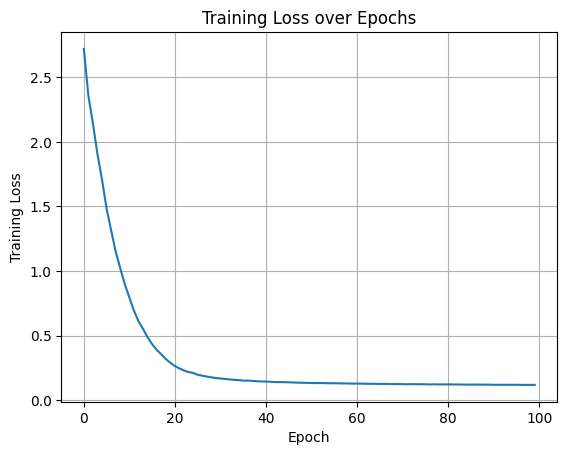

In [32]:
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

# Section 10: Compute Classification Metrics using Latent Features

In [33]:
!pip install imbalanced-learn

In [34]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)
from imblearn.over_sampling import RandomOverSampler

# 1) Extract latent features using model.encoder
model.eval()
latent_feats = []
batch_size = 256

with torch.no_grad():
    for i in range(0, adata_train.shape[0], batch_size):
        batch = adata_train.X[i:i+batch_size].toarray()
        x = torch.tensor(batch, dtype=torch.float32).to(device)
        z = model.encoder(x)
        latent_feats.append(z.cpu().numpy())

latent_feats = np.vstack(latent_feats)

# 2) Pull out raw metadata and extract 'type_fine'
raw_meta_col = adata_train.obs.columns[0]
raw_meta = adata_train.obs[raw_meta_col]
col_names = raw_meta_col.split(',')
type_idx = col_names.index('type_fine')
split_meta = raw_meta.str.split(',', n=len(col_names)-1, expand=True)
labels = split_meta.iloc[:, type_idx].values

# 3) Collapse rare labels into "Other" and encode
label_counts = pd.Series(labels).value_counts()
labels_collapsed = [
    lab if label_counts[lab] >= 5 else "Other"
    for lab in labels
]
labels = np.array(labels_collapsed)

le = LabelEncoder()
y = le.fit_transform(labels)

# 4) Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    latent_feats, y, test_size=0.2, random_state=42
)

# 4a) Balance training set with RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_tr, y_tr = ros.fit_resample(X_tr, y_tr)
print("After random oversampling, training class distribution:", np.bincount(y_tr))

# 5) Fit classifier with class weights
clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    solver='saga'
)
clf.fit(X_tr, y_tr)

# 6) Predict & compute metrics
y_pr = clf.predict(X_te)
acc = accuracy_score(y_te, y_pr)
prec = precision_score(y_te, y_pr, average='macro', zero_division=0)
rec = recall_score(y_te, y_pr, average='macro', zero_division=0)
f1mac = f1_score(y_te, y_pr, average='macro', zero_division=0)

print(f"Accuracy:        {acc:.4f}")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall:    {rec:.4f}")
print(f"Macro F1:        {f1mac:.4f}\n")

# Per-class breakdown for present labels only
present = np.unique(np.concatenate([y_te, y_pr]))

print("Per-class performance:\n")
print(classification_report(
    y_te,
    y_pr,
    labels=present,
    target_names=le.classes_[present],
    zero_division=0
))

After random oversampling, training class distribution: [46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46
 46 46 46 46 46 46 46 46 46]
Accuracy:        0.8400
Macro Precision: 0.8733
Macro Recall:    0.8446
Macro F1:        0.8366

Per-class performance:

                    precision    recall  f1-score   support

           Astro_A       1.00      0.83      0.91         6
           Astro_B       0.80      1.00      0.89         4
           Astro_D       1.00      1.00      1.00         5
           Astro_E       1.00      1.00      1.00         1
Endocyte_Capillary       1.00      0.50      0.67         4
          Exc_CUX2       1.00      1.00      1.00        10
   Exc_CUX2_RORB_A       1.00      1.00      1.00         4
   Exc_CUX2_RORB_C       1.00      1.00      1.00         1
        Exc_RORB_A       1.00      1.00      1.00         3
        Exc_RORB_B       1.00      1.00      1.00         2
        Exc_RORB_C       1.00      1.00      1.00         2


In [35]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [(128,), (128, 64), (256,)],
    'alpha': [1e-4, 1e-3],
    'learning_rate_init': [1e-3, 1e-4]
}
mlp = MLPClassifier(max_iter=500, random_state=42)
gs = GridSearchCV(
    mlp, param_grid, cv=3, scoring='f1_macro', n_jobs=-1
)
gs.fit(latent_feats, y)

print("Best MLP params:", gs.best_params_)
print("Best CV macro-F1:", gs.best_score_)

# Test eval
from sklearn.metrics import classification_report
y_pred = gs.predict(latent_feats)
print(classification_report(y, y_pred, target_names=le.classes_, zero_division=0))

✅ Best MLP params: {'alpha': 0.0001, 'hidden_layer_sizes': (256,), 'learning_rate_init': 0.0001}
✅ Best CV macro-F1: 0.8749462937766453
                    precision    recall  f1-score   support

           Astro_A       1.00      1.00      1.00        15
           Astro_B       1.00      1.00      1.00        10
           Astro_C       1.00      1.00      1.00         7
           Astro_D       0.95      1.00      0.98        21
           Astro_E       1.00      0.80      0.89         5
Endocyte_Capillary       0.93      1.00      0.97        14
          Exc_CUX2       1.00      1.00      1.00        38
   Exc_CUX2_RORB_A       0.95      1.00      0.97        36
   Exc_CUX2_RORB_B       1.00      1.00      1.00         5
   Exc_CUX2_RORB_C       1.00      1.00      1.00         5
        Exc_RORB_A       1.00      1.00      1.00         9
        Exc_RORB_B       1.00      1.00      1.00         6
        Exc_RORB_C       1.00      0.83      0.91         6
      Exc_THEMIS_A     

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# Section 11: Plot the Data


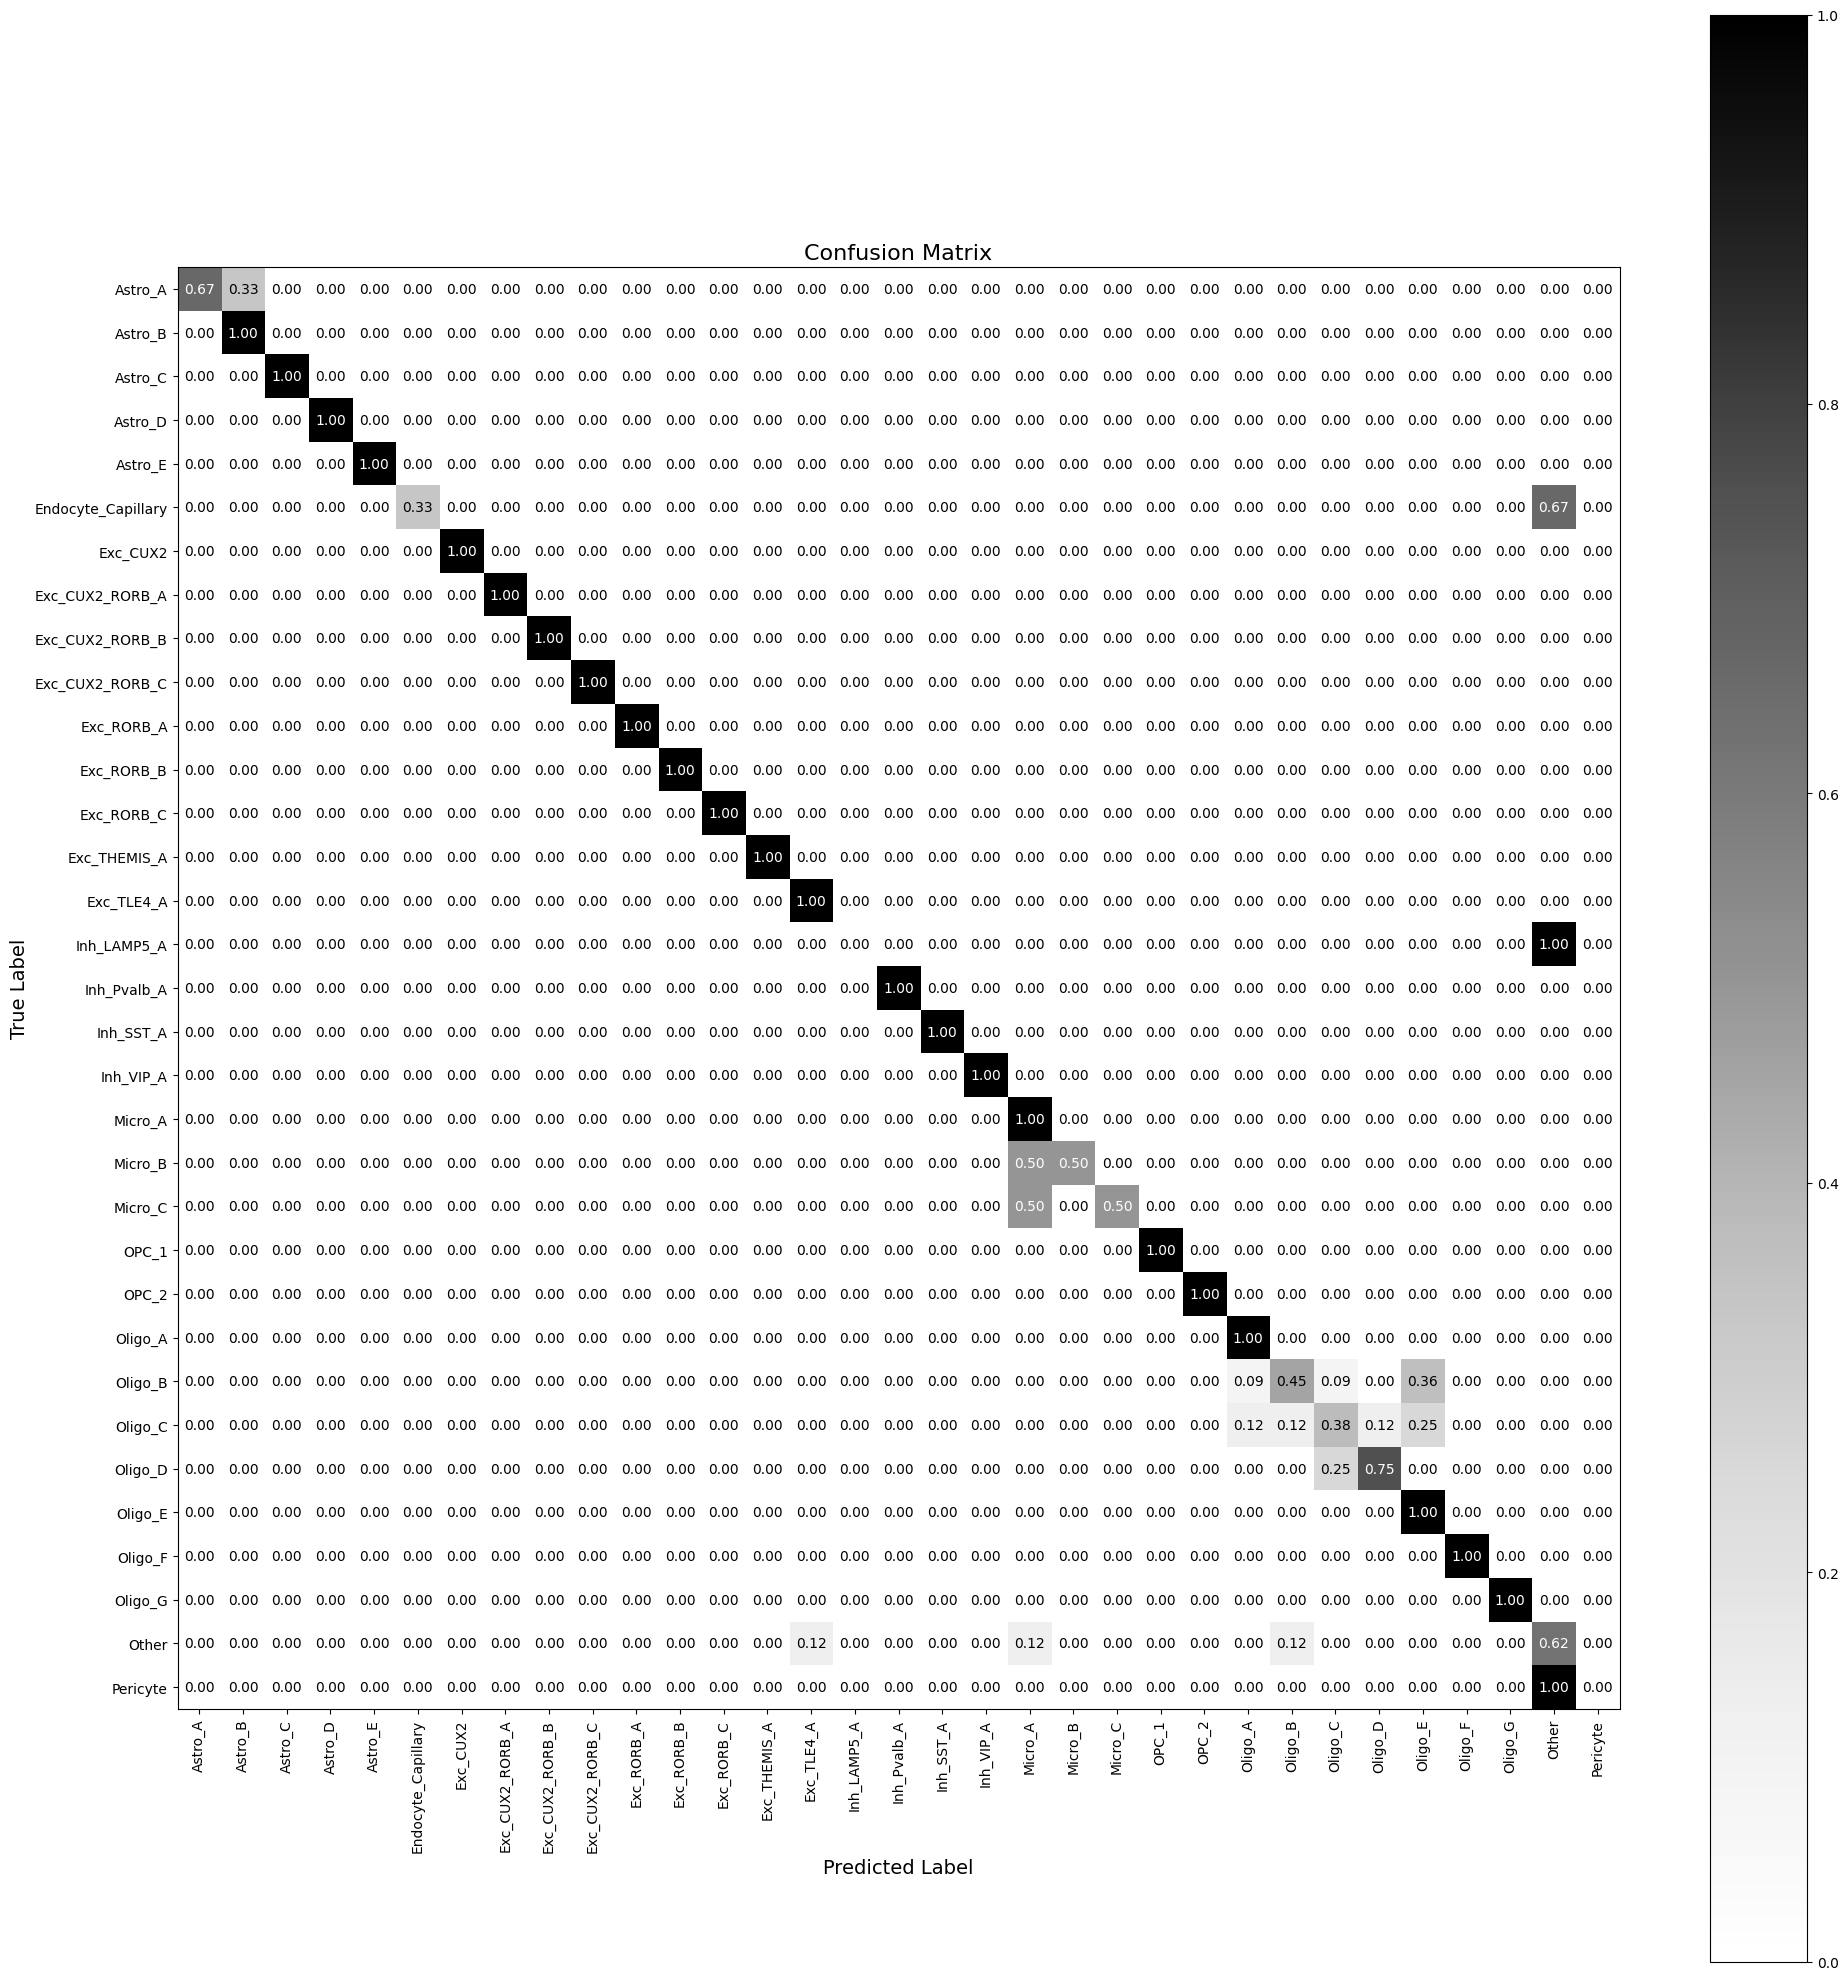

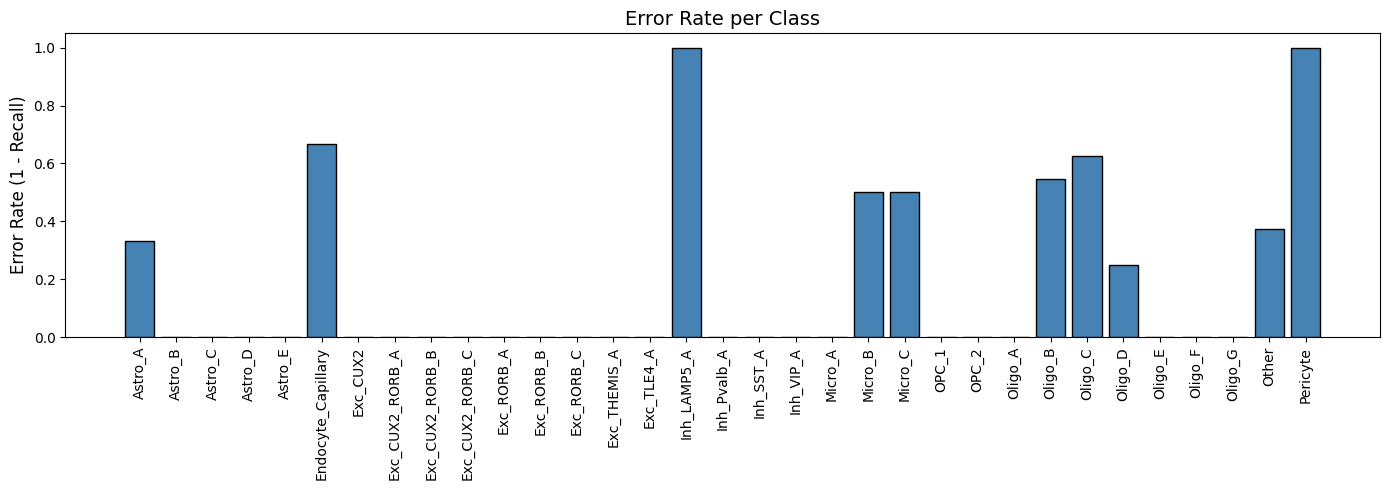

<ipython-input-42-a4b042c8bfea>:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(le.classes_))


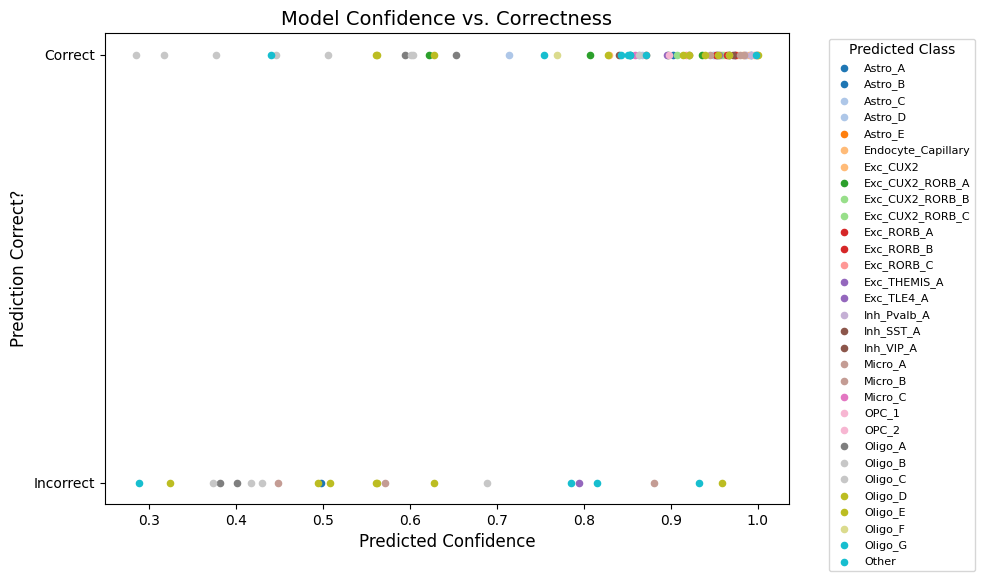

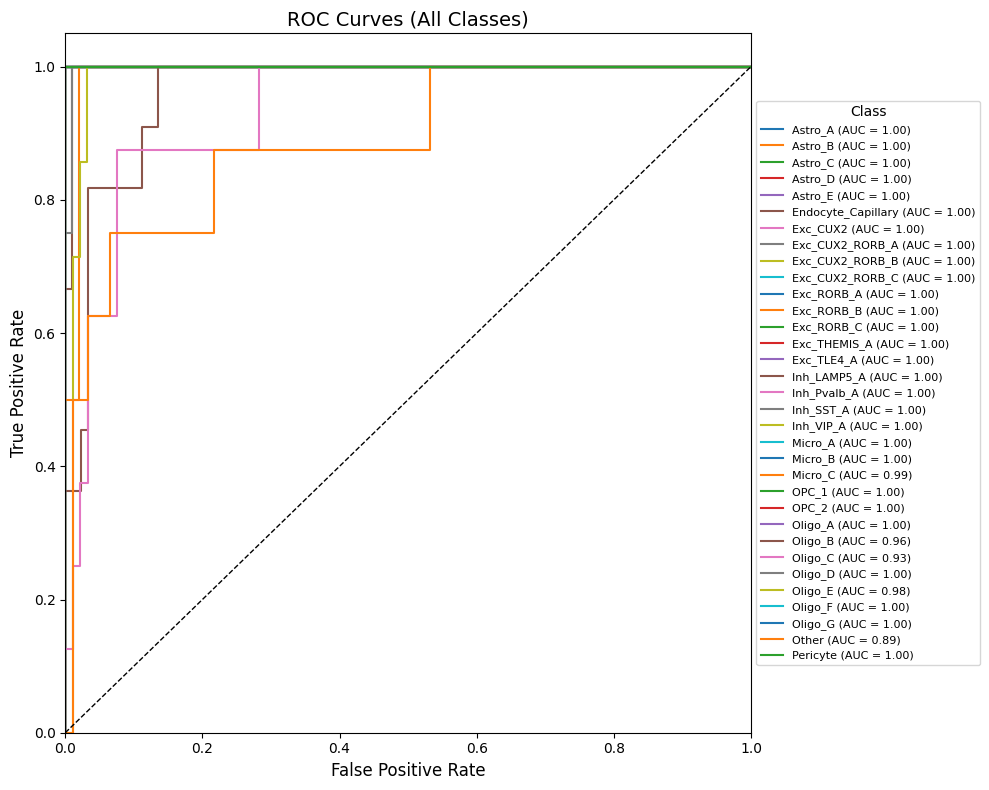

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    recall_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

model.eval()
latent_test = []
batch_size = 256

with torch.no_grad():
    for i in range(0, X_test_dense.shape[0], batch_size):
        batch = torch.tensor(X_test_dense[i:i+batch_size], dtype=torch.float32).to(device)
        z = model.encoder(batch)
        latent_test.append(z.cpu().numpy())

latent_test = np.vstack(latent_test)

# 1) Predict on latent space
y_pred = clf.predict(latent_test)
y_prob = clf.predict_proba(latent_test)

# 2) Confusion Matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Greys', xticks_rotation=90, values_format='0.2f', ax=ax)
ax.tick_params(axis='both', labelsize=10)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.set_title('Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.show()

# 3) Error Rate per Class
recalls = recall_score(y_test, y_pred, average=None, zero_division=0)
error_rate = 1.0 - recalls
classes = le.classes_

plt.figure(figsize=(14, 5))
plt.bar(classes, error_rate, color='steelblue', edgecolor='black')
plt.xticks(rotation=90)
plt.ylabel('Error Rate (1 - Recall)', fontsize=12)
plt.title('Error Rate per Class', fontsize=14)
plt.tight_layout()
plt.show()

# 4) Confidence vs. Correctness
confidences = np.max(y_prob, axis=1)
correctness = (y_pred == y_test).astype(int)

plt.figure(figsize=(10, 6))
colors = plt.cm.get_cmap('tab20', len(le.classes_))

for i, class_idx in enumerate(np.unique(y_pred)):
    idxs = np.where(y_pred == class_idx)[0]
    plt.scatter(confidences[idxs], correctness[idxs],
                label=le.classes_[class_idx], color=colors(i), s=20)

plt.yticks([0, 1], ['Incorrect', 'Correct'])
plt.xlabel('Predicted Confidence', fontsize=12)
plt.ylabel('Prediction Correct?', fontsize=12)
plt.title('Model Confidence vs. Correctness', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Predicted Class', fontsize=8)
plt.tight_layout()
plt.show()

# 5) ROC Curve
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
n_classes = y_test_bin.shape[1]
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=1.5, label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves (All Classes)', fontsize=14)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, title="Class")
plt.tight_layout()
plt.show()
